In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. User settings
# ============================================================

dmu_mn_fixed=0.0
dmu_h2o_fixed=0.0
dmu_o2_fixed=0.0

x_min=-4
x_max=0
n_points=400

fig_width=6.5
fig_height=4.5

# font / style settings
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})



# 2. Relative energy equations

### [001 Slab]
$ G_0 = 0  $

$G_1 = dG - Δμ_{Mn(OH)2}$

$G_2 = dG - Δμ_{Mn(OH)2} - 0.25Δμ_{O2} + 0.5Δμ_{H2O}$

$G_3 = dG - 2Δμ_{Mn(OH)2} - 0.25Δμ_{O2} + 1.5Δμ_{H2O}$

$G_4 = dG - 2Δμ_{Mn(OH)2} - 0.50Δμ_{O2} + 2.0Δμ_{H2O}$

$G_5 = dG - 3Δμ_{Mn(OH)2} - 0.50Δμ_{O2} + 3.0Δμ_{H2O} = G_r$


### [011 Slab]
$G_0 = 0$

$G_1 = -0.69 - 0.25Δμ_{Mn(OH)2} + 0.5Δμ_{H2O}$

$G_2 = -0.21 - Δμ_{Mn(OH)2} - 0.25*Δμ_{O2} + 1.5Δμ_{H2O}$

$G_3 = -0.76 - 2Δμ_{Mn(OH)2} - 0.25*Δμ_{O2} + 1.5Δμ_{H2O}$

$G_4 = -1.6 - 2Δμ_{Mn(OH)2} - 0.50*Δμ_{O2} + 2.0Δμ_{H2O}$

$G_5 = -1.68 - 3Δμ_{Mn(OH)2} - 0.50*Δμ_{O2} + 3.0Δμ_{H2O}  = G_r$ 


### [Calculate dE]
https://doi.org/10.1039/c9cc00754g 

$ TOF = (k_B*T/h) * e^{-dE/RT} $

$ dE = max_{ij} (T_i-I_j + dG_{ij}) $

$$
\delta G_{ij} = \begin{cases} 
0 & \text{if } T_i \text{ after } I_j \\ 
\Delta G_{\text{r}}^\circ & \text{if } T_i \text{ before } I_j 
\end{cases}
$$

In [14]:
def relative_energies_001(dmu_mn, dmu_h2o, dmu_o2):
    dmu_mn, dmu_h2o, dmu_o2 = np.broadcast_arrays(
        dmu_mn, dmu_h2o, dmu_o2
    )

    G0 = np.zeros_like(dmu_mn)
    G1 = -0.35 - dmu_mn
    G2 = -0.32 - dmu_mn - 0.25*dmu_o2 + 0.5*dmu_h2o
    G3 = -1.01 - 2*dmu_mn - 0.25*dmu_o2 + 1.5*dmu_h2o
    G4 = -2.29 - 2*dmu_mn - 0.50*dmu_o2 + 2.0*dmu_h2o
    G5 = -1.76 - 3*dmu_mn - 0.50*dmu_o2 + 3.0*dmu_h2o

    return G0, G1, G2, G3, G4, G5

def relative_energies_011(dmu_mn, dmu_h2o, dmu_o2):
    dmu_mn, dmu_h2o, dmu_o2 = np.broadcast_arrays(
        dmu_mn, dmu_h2o, dmu_o2
    )

    G0 = np.zeros_like(dmu_mn)

    G1 = -0.69 - 0.25*dmu_o2 + 0.5*dmu_h2o
    G2 = -0.21 - dmu_mn - 0.25*dmu_o2 + 1.5*dmu_h2o
    G3 = -0.76 - 2*dmu_mn - 0.25*dmu_o2 + 1.5*dmu_h2o
    G4 = -1.6 - 2*dmu_mn - 0.50*dmu_o2 + 2.0*dmu_h2o
    G5 = -1.68 - 3*dmu_mn - 0.50*dmu_o2 + 3.0*dmu_h2o

    return G0, G1, G2, G3, G4, G5


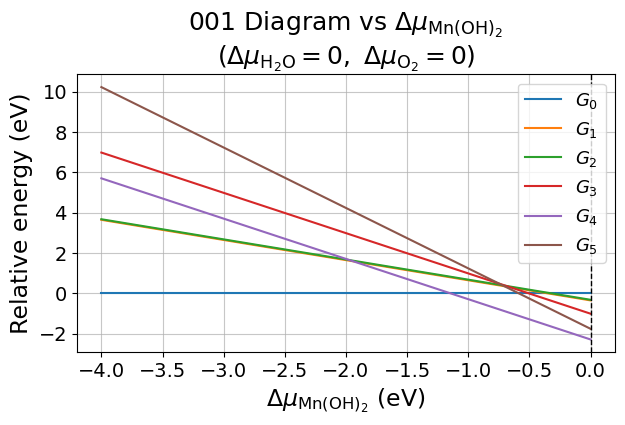

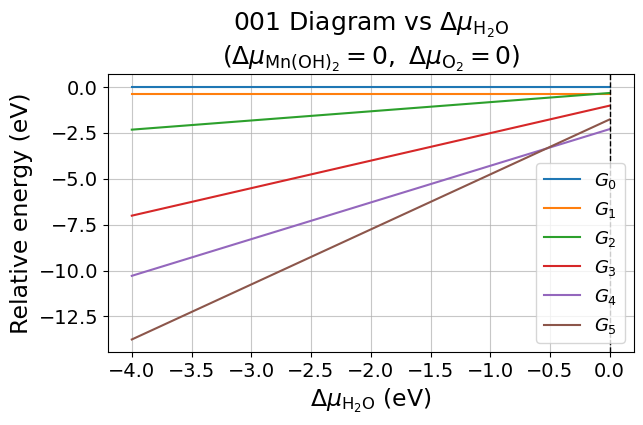

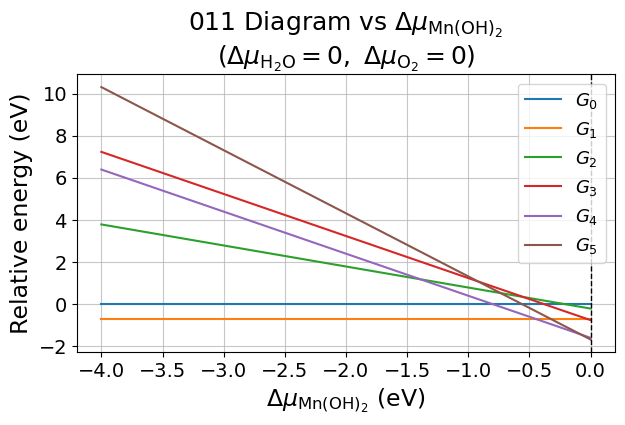

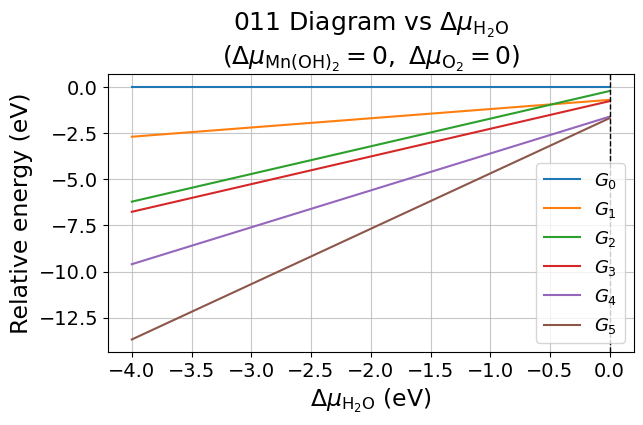

In [15]:
def plot_relative_energy(
    x_axis, relative_energies,
    x_min=x_min, x_max=x_max, n_points=n_points,
    dmu_mn_fixed=dmu_mn_fixed, dmu_h2o_fixed=dmu_h2o_fixed, dmu_o2_fixed=dmu_o2_fixed,
    fig_width=fig_width, fig_height=fig_height, facet_label="001"
    ):

    x = np.linspace(x_min, x_max, n_points)

    if x_axis == "mn":
        dmu_mn = x
        dmu_h2o = dmu_h2o_fixed
        dmu_o2 = dmu_o2_fixed

        xlabel = r'$\Delta \mu_{\mathrm{Mn(OH)_2}}$ (eV)'
        title = (
            rf'{facet_label} Diagram vs $\Delta \mu_{{\mathrm{{Mn(OH)_2}}}}$'
            '\n'
            r'$(\Delta \mu_{\mathrm{H_2O}} = 0,\ \Delta \mu_{\mathrm{O_2}} = 0)$'
        )

    elif x_axis == "h2o":
        dmu_mn = dmu_mn_fixed
        dmu_h2o = x
        dmu_o2 = dmu_o2_fixed

        xlabel = r'$\Delta \mu_{\mathrm{H_2O}}$ (eV)'
        title = (
            rf'{facet_label} Diagram vs $\Delta \mu_{{\mathrm{{H_2O}}}}$'
            '\n'
            r'$(\Delta \mu_{\mathrm{Mn(OH)_2}} = 0,\ \Delta \mu_{\mathrm{O_2}} = 0)$'
        )

    else:
        raise ValueError("x_axis must be either 'mn' or 'h2o'.")

    G_values = relative_energies(
        dmu_mn=dmu_mn,
        dmu_h2o=dmu_h2o,
        dmu_o2=dmu_o2
    )

    plt.figure(figsize=(fig_width, fig_height))

    for i, G in enumerate(G_values):
        plt.plot(x, G, label=rf'$G_{i}$')

    plt.axvline(0, linestyle='--', linewidth=1, c='black')
    plt.grid(True, which="both", linewidth=0.8, alpha=0.7)

    plt.xlabel(xlabel)
    plt.ylabel('Relative energy (eV)')
    plt.title(title)

    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

#=========main==============
plot_relative_energy(
    x_axis="mn",
    relative_energies=relative_energies_001,
    facet_label="001"
)

plot_relative_energy(
    x_axis="h2o",
    relative_energies=relative_energies_001,
    facet_label="001"
)

plot_relative_energy(
    x_axis="mn",
    relative_energies=relative_energies_011,
    facet_label="011"
)

plot_relative_energy(
    x_axis="h2o",
    relative_energies=relative_energies_011,
    facet_label="011"
)


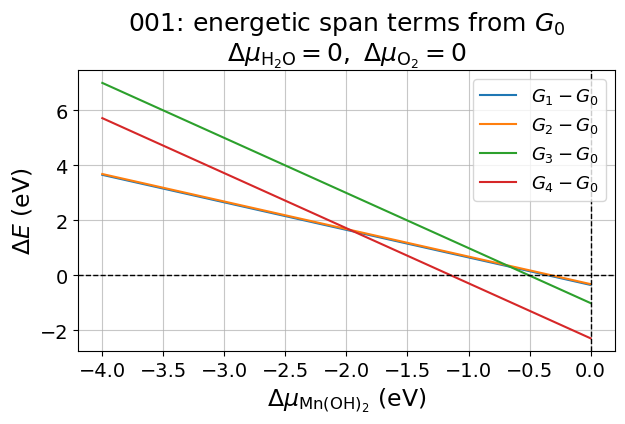

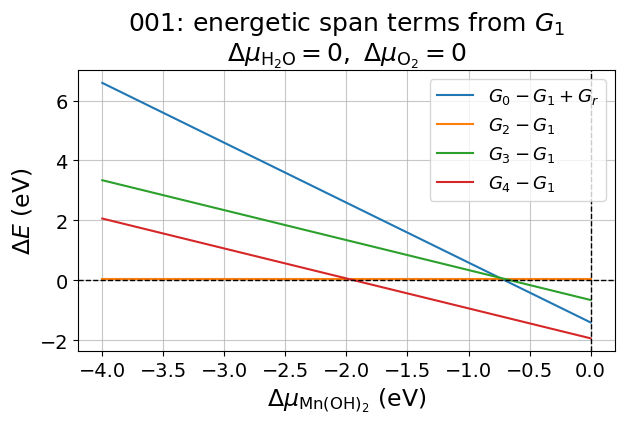

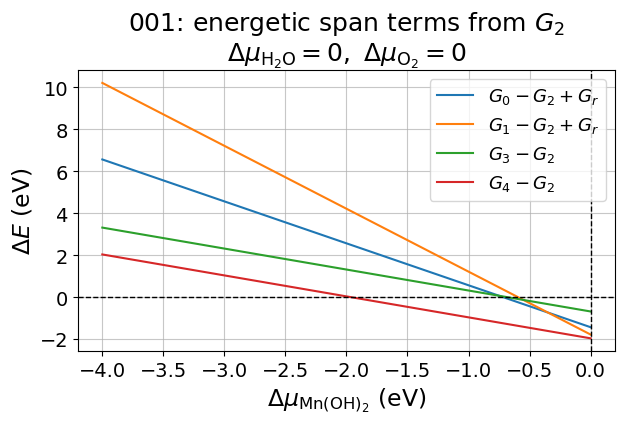

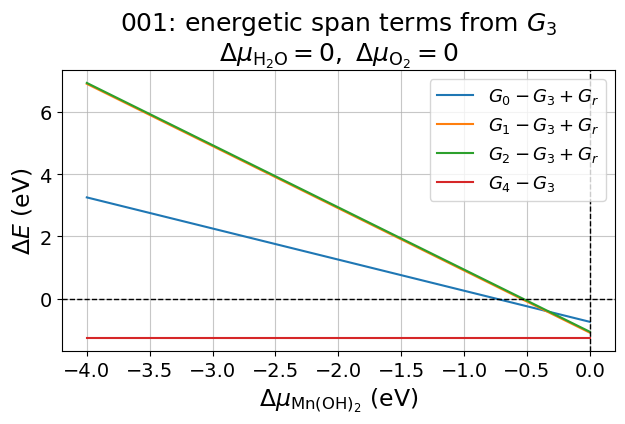

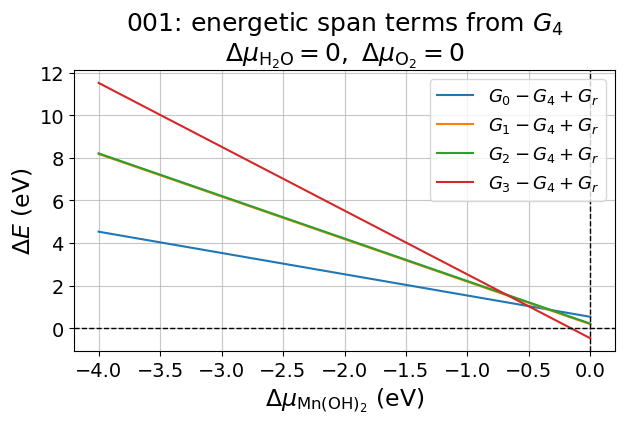

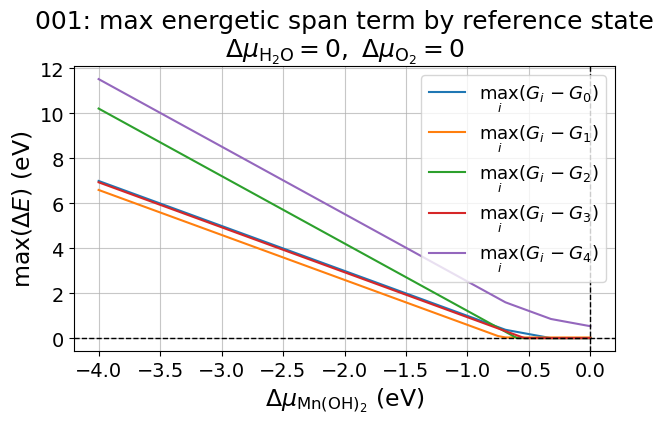

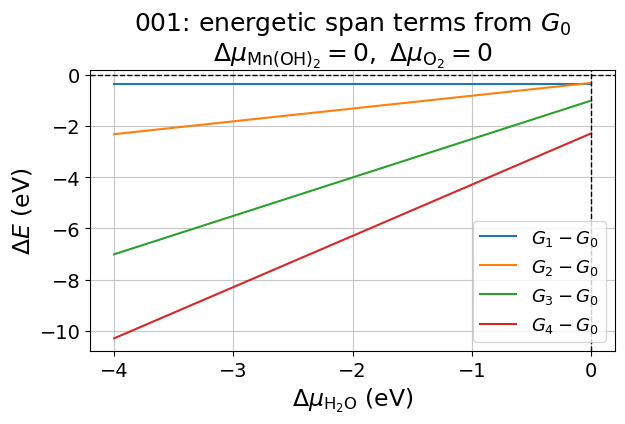

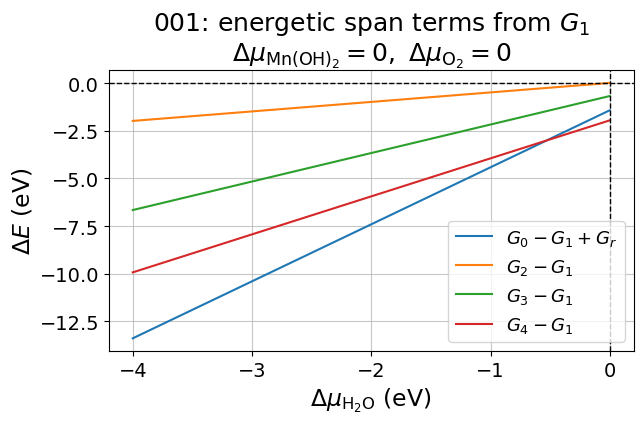

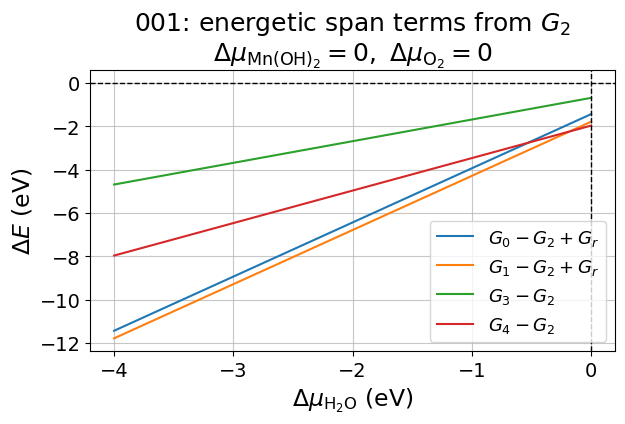

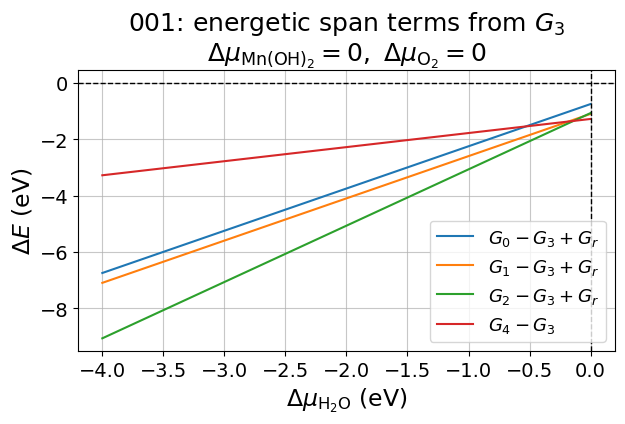

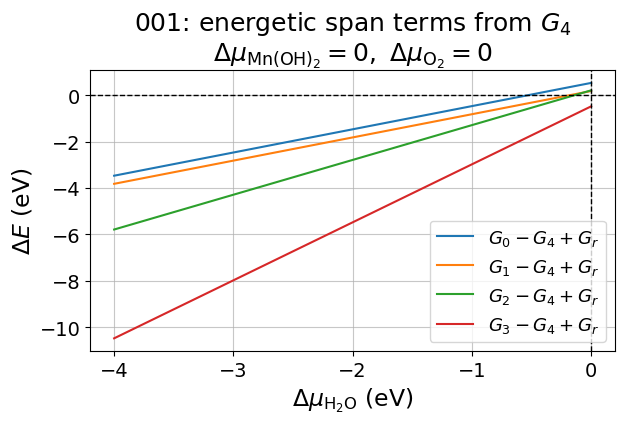

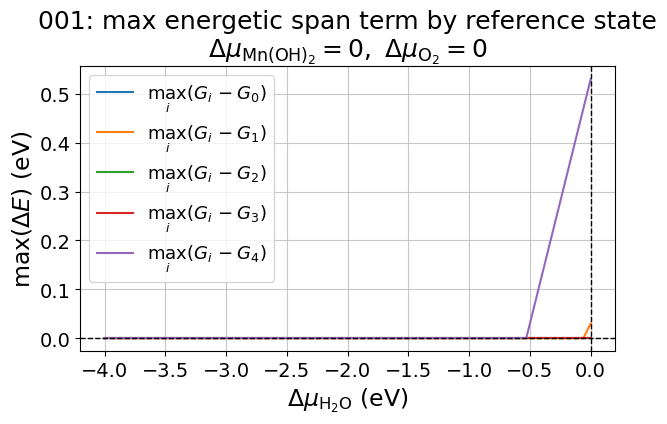

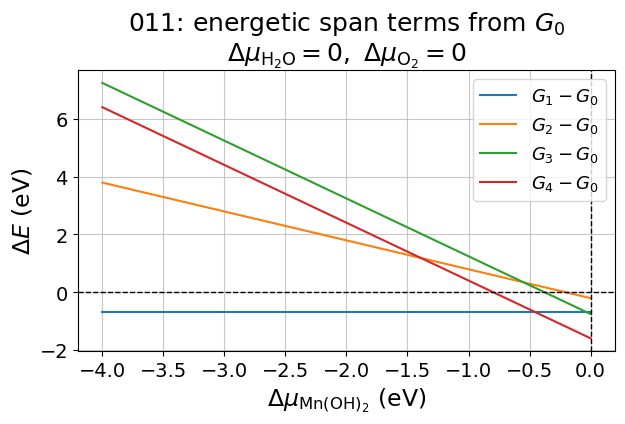

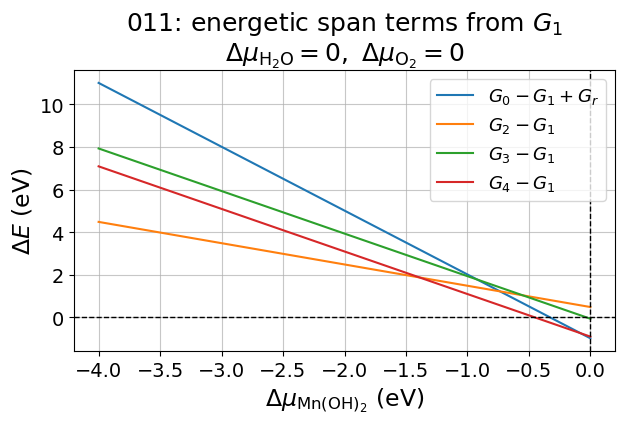

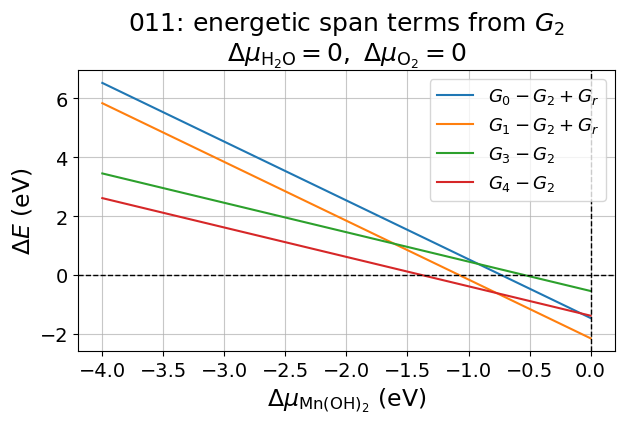

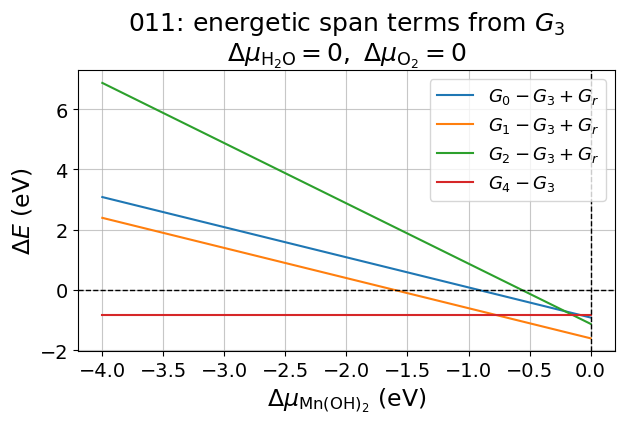

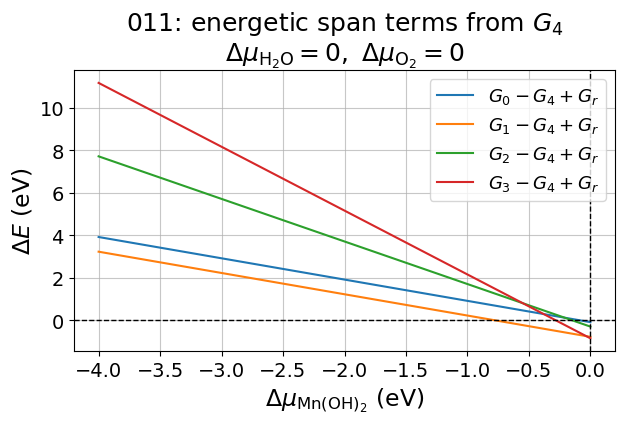

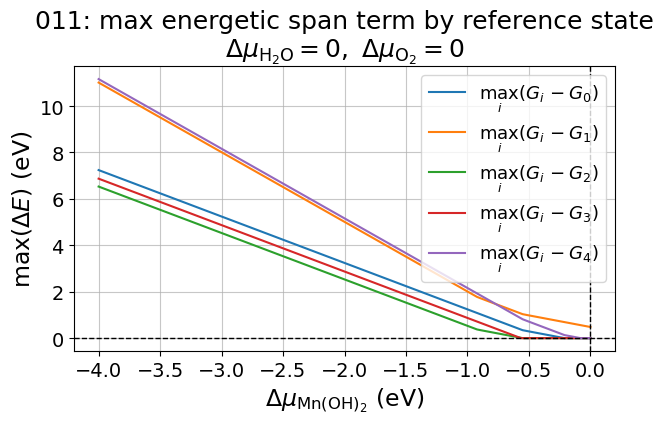

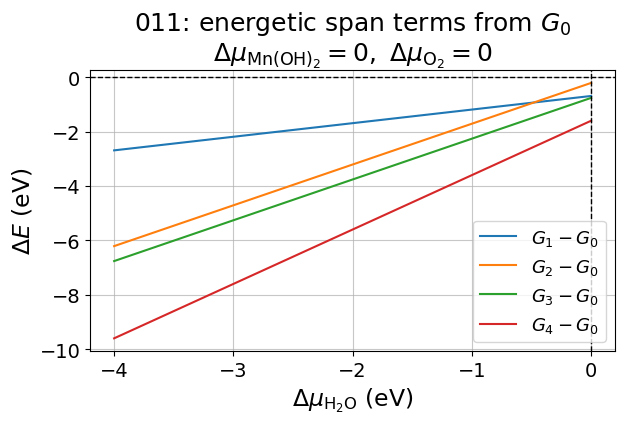

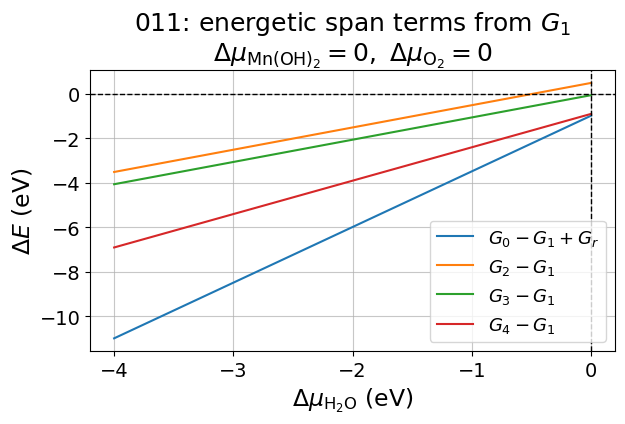

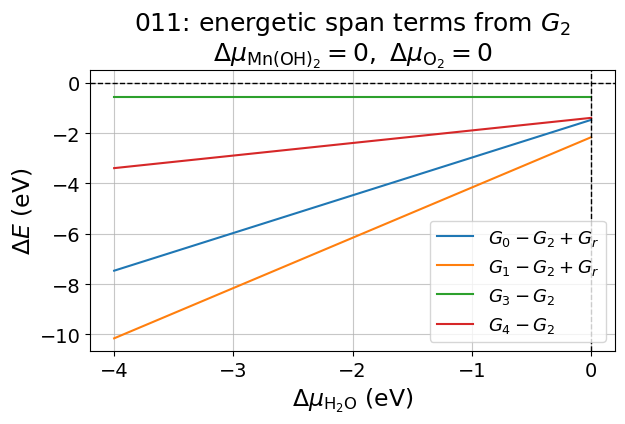

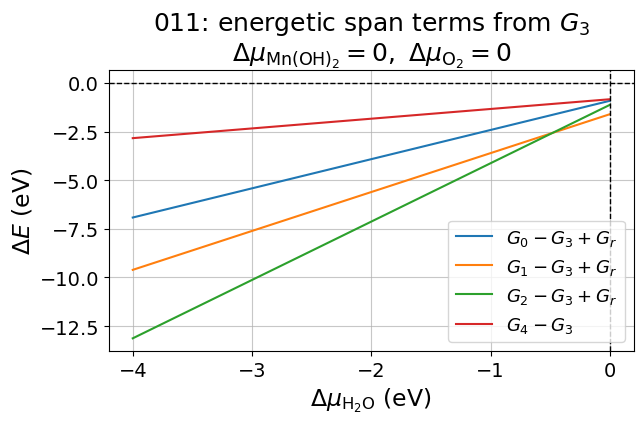

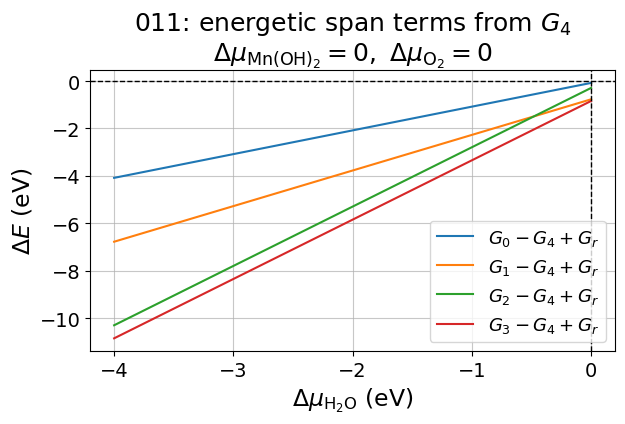

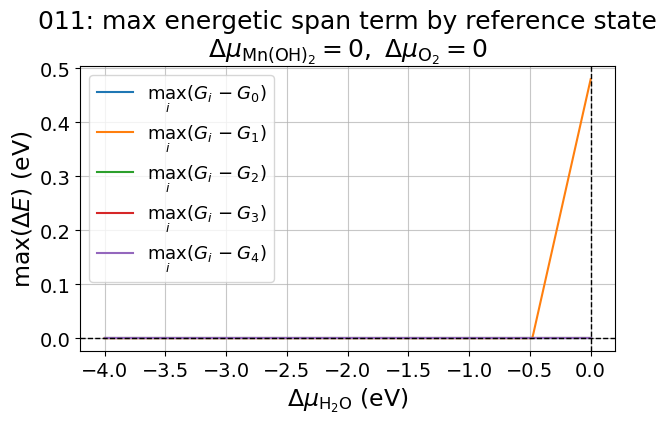

In [16]:
# Gi' = Gi + Gr
# dE 를 계산하기 위해선, 
# Gr = G5
# G0 에 대해 G1-G0, G2-G0, G3-G0, G4-G0,
# G1 에 대해 G0-G1+Gr, G2-G1, G3-G1, G4-G1,
# 등 .... 계산해서 매트릭스로 저장해두어야 함 

# 1)  각 G0, G1, G2, G3, G4 에 대해 그래프를 만들것 (5개)
# 2)  max (Gi-G0), max (Gi-G1) ... 을 범례로 하는 그래프를 만들 것(1개)

def make_mu_scan(
    x_axis,
    x_min=x_min, x_max=x_max, n_points=n_points,
    dmu_mn_fixed=dmu_mn_fixed, dmu_h2o_fixed=dmu_h2o_fixed,
    dmu_o2_fixed=dmu_o2_fixed,
):
    x = np.linspace(x_min, x_max, n_points)

    if x_axis == "mn":
        dmu_mn = x
        dmu_h2o = dmu_h2o_fixed
        dmu_o2 = dmu_o2_fixed
        xlabel = r'$\Delta \mu_{\mathrm{Mn(OH)_2}}$ (eV)'
        fixed_label = (
            r'$\Delta \mu_{\mathrm{H_2O}} = 0,\ '
            r'\Delta \mu_{\mathrm{O_2}} = 0$'
        )
    elif x_axis == "h2o":
        dmu_mn = dmu_mn_fixed
        dmu_h2o = x
        dmu_o2 = dmu_o2_fixed
        xlabel = r'$\Delta \mu_{\mathrm{H_2O}}$ (eV)'
        fixed_label = (
            r'$\Delta \mu_{\mathrm{Mn(OH)_2}} = 0,\ '
            r'\Delta \mu_{\mathrm{O_2}} = 0$'
        )
    else:
        raise ValueError("x_axis must be either 'mn' or 'h2o'.")

    return x, dmu_mn, dmu_h2o, dmu_o2, xlabel, fixed_label


def energetic_span_matrix(relative_energies, dmu_mn, dmu_h2o, dmu_o2):
    G_values = relative_energies(
        dmu_mn=dmu_mn,
        dmu_h2o=dmu_h2o,
        dmu_o2=dmu_o2,
    )

    intermediates = np.array(G_values[:5])
    Gr = G_values[5]
    n_intermediates = len(intermediates)
    dE_matrix = np.empty((n_intermediates, n_intermediates, *np.shape(Gr)))

    for reference_idx in range(n_intermediates):
        for target_idx in range(n_intermediates):
            dE = intermediates[target_idx] - intermediates[reference_idx]
            if target_idx < reference_idx:
                dE = dE + Gr
            dE_matrix[reference_idx, target_idx] = dE

    return dE_matrix


def plot_energetic_span_by_reference(
    x_axis, relative_energies, facet_label="001",
    x_min=x_min, x_max=x_max, n_points=n_points,
    dmu_mn_fixed=dmu_mn_fixed, dmu_h2o_fixed=dmu_h2o_fixed,
    dmu_o2_fixed=dmu_o2_fixed,
    fig_width=fig_width, fig_height=fig_height,
):
    x, dmu_mn, dmu_h2o, dmu_o2, xlabel, fixed_label = make_mu_scan(
        x_axis=x_axis,
        x_min=x_min,
        x_max=x_max,
        n_points=n_points,
        dmu_mn_fixed=dmu_mn_fixed,
        dmu_h2o_fixed=dmu_h2o_fixed,
        dmu_o2_fixed=dmu_o2_fixed,
    )
    dE_matrix = energetic_span_matrix(relative_energies, dmu_mn, dmu_h2o, dmu_o2)

    for reference_idx in range(dE_matrix.shape[0]):
        plt.figure(figsize=(fig_width, fig_height))

        for target_idx in range(dE_matrix.shape[1]):
            if target_idx == reference_idx:
                continue
            label = rf'$G_{target_idx} - G_{reference_idx}$'
            if target_idx < reference_idx:
                label = label[:-1] + r' + G_r$'
            plt.plot(x, dE_matrix[reference_idx, target_idx], label=label)

        plt.axhline(0, linestyle='--', linewidth=1, c='black')
        plt.axvline(0, linestyle='--', linewidth=1, c='black')
        plt.grid(True, which="both", linewidth=0.8, alpha=0.7)
        plt.xlabel(xlabel)
        plt.ylabel(r'$\Delta E$ (eV)')
        plt.title(
            rf'{facet_label}: energetic span terms from $G_{reference_idx}$'
            '\n'
            + fixed_label
        )
        plt.legend(frameon=True)
        plt.tight_layout()
        plt.show()
        plt.close()

    plt.figure(figsize=(fig_width, fig_height))
    reference_max = np.max(dE_matrix, axis=1)

    for reference_idx, dE_max in enumerate(reference_max):
        plt.plot(x, dE_max, label=rf'$\max_i(G_i - G_{reference_idx})$')

    plt.axhline(0, linestyle='--', linewidth=1, c='black')
    plt.axvline(0, linestyle='--', linewidth=1, c='black')
    plt.grid(True, which="both", linewidth=0.8, alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel(r'$\max(\Delta E)$ (eV)')
    plt.title(
        rf'{facet_label}: max energetic span term by reference state'
        '\n'
        + fixed_label
    )
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    plt.close()

    return x, dE_matrix, reference_max


#=========main==============
x_001_mn, dE_matrix_001_mn, dE_max_001_mn = plot_energetic_span_by_reference(
    x_axis="mn",
    relative_energies=relative_energies_001,
    facet_label="001",
)

x_001_h2o, dE_matrix_001_h2o, dE_max_001_h2o = plot_energetic_span_by_reference(
    x_axis="h2o",
    relative_energies=relative_energies_001,
    facet_label="001",
)

x_011_mn, dE_matrix_011_mn, dE_max_011_mn = plot_energetic_span_by_reference(
    x_axis="mn",
    relative_energies=relative_energies_011,
    facet_label="011",
)

x_011_h2o, dE_matrix_011_h2o, dE_max_011_h2o = plot_energetic_span_by_reference(
    x_axis="h2o",
    relative_energies=relative_energies_011,
    facet_label="011",
)

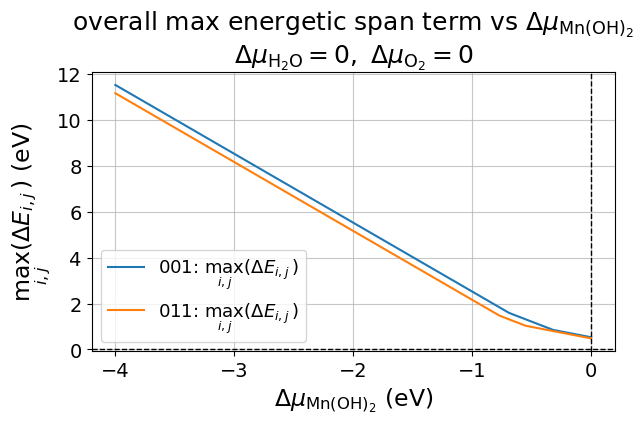

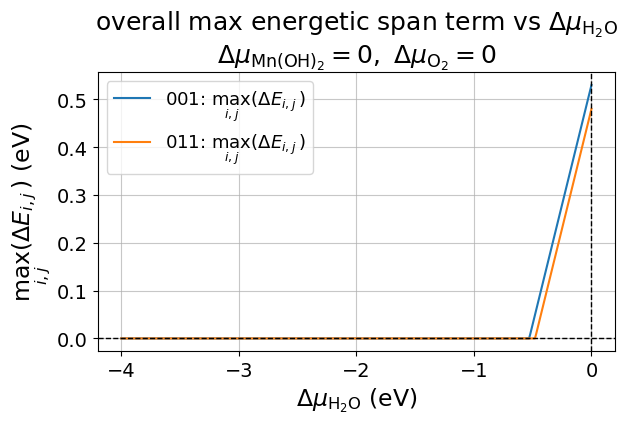

In [17]:
def plot_max_ij_energetic_span_comparison(
    x_axis, x_001, dE_max_001, x_011, dE_max_011,
    fig_width=fig_width, fig_height=fig_height,
):
    if not np.allclose(x_001, x_011):
        raise ValueError("001 and 011 x grids are different.")

    _, _, _, _, xlabel, fixed_label = make_mu_scan(x_axis=x_axis)
    dE_max_ij_001 = np.max(dE_max_001, axis=0)
    dE_max_ij_011 = np.max(dE_max_011, axis=0)

    if x_axis == "mn":
        title_axis = r'$\Delta \mu_{\mathrm{Mn(OH)_2}}$'
    elif x_axis == "h2o":
        title_axis = r'$\Delta \mu_{\mathrm{H_2O}}$'
    else:
        raise ValueError("x_axis must be either 'mn' or 'h2o'.")

    plt.figure(figsize=(fig_width, fig_height))
    plt.plot(x_001, dE_max_ij_001, label=r'001: $\max_{i,j}(\Delta E_{i,j})$')
    plt.plot(x_001, dE_max_ij_011, label=r'011: $\max_{i,j}(\Delta E_{i,j})$')
    plt.axhline(0, linestyle='--', linewidth=1, c='black')
    plt.axvline(0, linestyle='--', linewidth=1, c='black')
    plt.grid(True, which="both", linewidth=0.8, alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel(r'$\max_{i,j}(\Delta E_{i,j})$ (eV)')
    plt.title(
        r'overall max energetic span term vs ' + title_axis
        + '\n'
        + fixed_label
    )
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    plt.close()

    return x_001, dE_max_ij_001, dE_max_ij_011


x_max_ij_mn, dE_max_ij_001_mn, dE_max_ij_011_mn = plot_max_ij_energetic_span_comparison(
    x_axis="mn",
    x_001=x_001_mn,
    dE_max_001=dE_max_001_mn,
    x_011=x_011_mn,
    dE_max_011=dE_max_011_mn,
)

x_max_ij_h2o, dE_max_ij_001_h2o, dE_max_ij_011_h2o = plot_max_ij_energetic_span_comparison(
    x_axis="h2o",
    x_001=x_001_h2o,
    dE_max_001=dE_max_001_h2o,
    x_011=x_011_h2o,
    dE_max_011=dE_max_011_h2o,
)

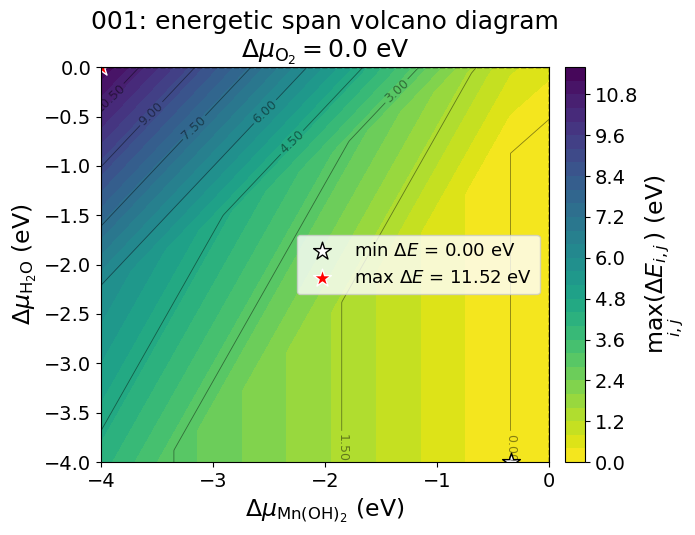

In [21]:
def plot_energetic_span_volcano_001(
    dmu_mn_min=x_min, dmu_mn_max=x_max,
    dmu_h2o_min=x_min, dmu_h2o_max=x_max,
    n_points_2d=n_points,
    dmu_o2_fixed=dmu_o2_fixed,
    fig_width=7.2, fig_height=5.6,
    n_levels=30,
):
    dmu_mn_values = np.linspace(dmu_mn_min, dmu_mn_max, n_points_2d)
    dmu_h2o_values = np.linspace(dmu_h2o_min, dmu_h2o_max, n_points_2d)
    dmu_mn_grid, dmu_h2o_grid = np.meshgrid(
        dmu_mn_values,
        dmu_h2o_values,
        indexing="xy",
    )

    dE_matrix = energetic_span_matrix(
        relative_energies=relative_energies_001,
        dmu_mn=dmu_mn_grid,
        dmu_h2o=dmu_h2o_grid,
        dmu_o2=dmu_o2_fixed,
    )
    dE_max_ij = np.max(dE_matrix, axis=(0, 1))

    min_idx = np.unravel_index(np.argmin(dE_max_ij), dE_max_ij.shape)
    dmu_mn_min_dE = dmu_mn_grid[min_idx]
    dmu_h2o_min_dE = dmu_h2o_grid[min_idx]
    min_dE = dE_max_ij[min_idx]
    max_idx = np.unravel_index(np.argmax(dE_max_ij), dE_max_ij.shape)
    dmu_mn_max_dE = dmu_mn_grid[max_idx]
    dmu_h2o_max_dE = dmu_h2o_grid[max_idx]
    max_dE = dE_max_ij[max_idx]

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    filled = ax.contourf(
        dmu_mn_grid,
        dmu_h2o_grid,
        dE_max_ij,
        levels=n_levels,
        cmap="viridis_r",
    )
    contour = ax.contour(
        dmu_mn_grid,
        dmu_h2o_grid,
        dE_max_ij,
        levels=8,
        colors="black",
        linewidths=0.6,
        alpha=0.45,
    )
    ax.clabel(contour, inline=True, fontsize=9, fmt="%.2f")
    ax.scatter(
        dmu_mn_min_dE,
        dmu_h2o_min_dE,
        marker="*",
        s=180,
        c="white",
        edgecolors="black",
        linewidths=1.0,
        label=rf'min $\Delta E$ = {min_dE:.2f} eV',
    )
    ax.scatter(
        dmu_mn_max_dE,
        dmu_h2o_max_dE,
        marker="*",
        s=180,
        c="red",
        edgecolors="white",
        linewidths=1.0,
        label=rf'max $\Delta E$ = {max_dE:.2f} eV',
    )
    ax.axhline(0, linestyle='--', linewidth=1, c='black')
    ax.axvline(0, linestyle='--', linewidth=1, c='black')
    ax.set_xlabel(r'$\Delta \mu_{\mathrm{Mn(OH)_2}}$ (eV)')
    ax.set_ylabel(r'$\Delta \mu_{\mathrm{H_2O}}$ (eV)')
    ax.set_title(
        r'001: energetic span volcano diagram'
        + '\n'
        + rf'$\Delta \mu_{{\mathrm{{O_2}}}} = {dmu_o2_fixed}$ eV'
    )
    ax.legend(frameon=True, loc="best")
    cbar = fig.colorbar(filled, ax=ax, pad=0.03)
    cbar.set_label(r'$\max_{i,j}(\Delta E_{i,j})$ (eV)')
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    return dmu_mn_grid, dmu_h2o_grid, dE_max_ij


dmu_mn_volcano_001, dmu_h2o_volcano_001, dE_volcano_001 = plot_energetic_span_volcano_001()